In [1]:
import os
import pandas as pd
import google_conf
import gzip
import pandas as pd
import json

In [2]:
mops_data = google_conf.setup(
    sheet_url="https://docs.google.com/spreadsheets/d/1VbCIAJssHKV9hlRTwzVFfm40CGnHesq53KXjv2qy4OM/edit?usp=sharing",
    service_account_path="../../../ServiceAccountsKey.json")

In [5]:
mops_data.worksheets()

[<Worksheet 'journals_annotated' id:913261822>,
 <Worksheet 'metadata_df' id:1084902874>,
 <Worksheet 'journals_religion_counts' id:614264725>,
 <Worksheet 'paul_hits_density' id:1788580417>,
 <Worksheet 'paul_hits_sample' id:493158726>]

In [6]:
journals_annotated = google_conf.get_as_dataframe(mops_data.worksheet("journals_annotated"))

In [7]:
journals_annotated.sample(10)

,Journal,Background,Unnamed: 2,confession-codex,discipline-codex,Publisher,On behalf of,Other
65,Scottish Journal of Theology,Protestant,NaN,Protestant,theology,Cambridge University Press,NaN,CUP since 2022
25,The Annual of the Society of Christian Ethics,systematic,non-confessional,Protestant,philosophy/ethics,Georgetown University Press,NaN,NaN
59,Gregorianum,Catholic,NaN,Catholic,theology,Gregorian University Press,Pontifical Gregorian University,NaN
74,Journal of the American Academy of Religion,non-confessional,NaN,Protestant,religion/culture,Oxford University Press,American Academy of Religion,NaN
34,Religion in Southern Africa,systematic,non-confessional,Independent/non-denominational,religion/culture,Association for the Study of Religion in South...,NaN,NaN
69,Church History,non-confessional,NaN,Protestant,religious history,Cambridge University Press,American Society of Church History,NaN
26,Mystics Quarterly,systematic,non-confessional,Independent/non-denominational,religious history,Penn State University Press,NaN,NaN
13,Buddhist-Christian Studies,systematic,non-confessional,Independent/non-denominational,religion/culture,University of Hawaiʻi Press,NaN,NaN
82,The Biblical World,non-confessional,NaN,Protestant,biblical/early Christian,University of Chicago Press,NaN,NaN
29,Journal of Africana Religions,systematic,non-confessional,Independent/non-denominational,religion/culture,Penn State University Press,NaN,NaN


In [8]:
#chunks = []
#for chunk in pd.read_json("/srv/data/jstor/jstor2026-04/jstor_metadata_2026-04-28.jsonl", lines=True, chunksize=10000):
    # Process/filter each chunk if needed
#    chunks.append(chunk)

#metadata_full = pd.concat(chunks, ignore_index=True)#%%

In [28]:
JSTOR_METADATA_JSONL = "/srv/data/jstor/jstor2026-04/jstor_metadata_2026-04-28.jsonl"


def jstor_metadata_chunks(chunksize=5_000, columns=None):
    """Stream the 13.7 GB metadata JSONL as a lazy sequence of DataFrames.

    Why not `pd.read_json(path, lines=True)` in one go: that asks pandas to
    build a single 384,829-row frame from ~36 KB of JSON per record (~13.7 GB
    of text) and will exhaust memory. Here pandas parses `chunksize` lines at a
    time and only one chunk is alive at once (~5k rows ≈ 180 MB peak before
    `columns` is applied, less after).

    `columns` selects the fields to keep before yielding, so the caller never
    sees the heavy nested entries it does not need. Read everything by looping
    and reducing the chunks yourself; nothing is cached between iterations.

    >>> n_eng = 0
    >>> for chunk in jstor_metadata_chunks(columns=["languages"]):
    ...     n_eng += chunk["languages"].apply(lambda ls: "eng" in ls).sum()
    """
    reader = pd.read_json(JSTOR_METADATA_JSONL, lines=True, chunksize=chunksize)
    for chunk in reader:
        yield chunk[columns] if columns is not None else chunk


# one-chunk peek (1000 records) to see the real fields and their dtypes
peek = next(jstor_metadata_chunks(chunksize=1_000))
peek.info()
peek.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   item_id                1000 non-null   object 
 1   review_required        1000 non-null   bool   
 2   ithaka_doi             1000 non-null   object 
 3   identifiers            1000 non-null   object 
 4   title                  999 non-null    object 
 5   is_part_of             975 non-null    object 
 6   creators_string        511 non-null    object 
 7   creators               479 non-null    object 
 8   publishers             601 non-null    object 
 9   published_date         965 non-null    object 
 10  languages              601 non-null    object 
 11  discipline_names       558 non-null    object 
 12  issue_number           280 non-null    float64
 13  issue_volume           0 non-null      float64
 14  c5_data_type           1000 non-null   object 
 15  c5_se

,item_id,review_required,ithaka_doi,identifiers,title,is_part_of,creators_string,creators,publishers,published_date,...,c5_data_type,c5_section_type,content_type,content_subtype,ccda_resource_type,ccda_resource_subtype,collections,contributed_content,licensing_status,url
0,81e94608-c4dc-3e28-b08e-7efc0f19553c,False,10.2307/community.37317744,"{'print_isbn': None, 'online_isbn': None, 'pri...",None,None,None,None,None,None,...,Other,Other,contributed_content,contributed_content_documents,Documents,Oral Histories,[Student Activism],True,Creative Commons: Attribution-NonCommercial-No...,www.jstor.org/stable/10.2307/community.37317744
1,3bd59245-4fdc-37a5-ad1d-fac00ed360b5,False,10.2307/resrep05076.15,"{'print_isbn': None, 'online_isbn': None, 'pri...",APPENDIX D – TABLE 3,None,None,None,[Center for Security Policy],2011-01-0,...,Report,Other,multi_part_research_report_part,Other,None,None,None,False,open_access,www.jstor.org/stable/10.2307/resrep05076.15


,item_id,review_required,ithaka_doi,identifiers,title,is_part_of,creators_string,creators,publishers,published_date,...,c5_data_type,c5_section_type,content_type,content_subtype,ccda_resource_type,ccda_resource_subtype,collections,contributed_content,licensing_status,url
0,81e94608-c4dc-3e28-b08e-7efc0f19553c,False,10.2307/community.37317744,"{'print_isbn': None, 'online_isbn': None, 'pri...",None,None,None,None,None,None,...,Other,Other,contributed_content,contributed_content_documents,Documents,Oral Histories,[Student Activism],True,Creative Commons: Attribution-NonCommercial-No...,www.jstor.org/stable/10.2307/community.37317744
1,3bd59245-4fdc-37a5-ad1d-fac00ed360b5,False,10.2307/resrep05076.15,"{'print_isbn': None, 'online_isbn': None, 'pri...",APPENDIX D – TABLE 3,None,None,None,[Center for Security Policy],2011-01-0,...,Report,Other,multi_part_research_report_part,Other,None,None,None,False,open_access,www.jstor.org/stable/10.2307/resrep05076.15
2,5513359a-3505-3010-8edd-a5281ab9edce,False,10.2307/resrep05076.17,"{'print_isbn': None, 'online_isbn': None, 'pri...",APPENDIX F – TABLE 5,None,None,None,[Center for Security Policy],2011-01-0,...,Report,Other,multi_part_research_report_part,Other,None,None,None,False,open_access,www.jstor.org/stable/10.2307/resrep05076.17
3,b0bbc294-d989-314e-b9b1-3a23ed7de3d6,False,10.2307/resrep05076.20,"{'print_isbn': None, 'online_isbn': None, 'pri...",APPENDIX I - CHART 2,None,None,None,[Center for Security Policy],2011-01-0,...,Report,Other,multi_part_research_report_part,Other,None,None,None,False,open_access,www.jstor.org/stable/10.2307/resrep05076.20
4,6ec06ea9-044a-3e77-96d7-029248f98cad,False,10.2307/resrep05076.22,"{'print_isbn': None, 'online_isbn': None, 'pri...",APPENDIX K – CHART 4,None,None,None,[Center for Security Policy],2011-01-0,...,Report,Other,multi_part_research_report_part,Other,None,None,None,False,open_access,www.jstor.org/stable/10.2307/resrep05076.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,d5f22265-bc09-3a5d-ad03-f3e9d3f1b191,False,10.2307/community.32711055,"{'print_isbn': None, 'online_isbn': None, 'pri...","""Gay Conference"" - Clippings, 1974, Item 17","""Gay Conference"" - Clippings, 1974, Item 17",None,None,None,1974-01-0,...,Other,Other,contributed_content,contributed_content_documents,Documents,Documents,[Student Activism],True,Creative Commons: Attribution-NonCommercial-No...,www.jstor.org/stable/10.2307/community.32711055
996,c4fab0cc-d840-3f2b-8442-64c194b1cb98,False,10.2307/community.32711056,"{'print_isbn': None, 'online_isbn': None, 'pri...","""Gay Conference"" - Clippings, 1974, Item 18","""Gay Conference"" - Clippings, 1974, Item 18",None,None,None,1974-01-0,...,Other,Other,contributed_content,contributed_content_documents,Documents,Documents,[Student Activism],True,Creative Commons: Attribution-NonCommercial-No...,www.jstor.org/stable/10.2307/community.32711056
997,9a8a4f24-75c4-3503-bd3d-92c78201cc8b,False,10.2307/community.32711057,"{'print_isbn': None, 'online_isbn': None, 'pri...","""Gay Conference"" - Clippings, 1974, Item 19","""Gay Conference"" - Clippings, 1974, Item 19",None,None,None,1974-01-0,...,Other,Other,contributed_content,contributed_content_documents,Documents,Documents,[Student Activism],True,Creative Commons: Attribution-NonCommercial-No...,www.jstor.org/stable/10.2307/community.32711057
998,e961cad6-d5e6-389f-9399-7ed0a42a7f84,False,10.2307/community.32711058,"{'print_isbn': None, 'online_isbn': None, 'pri...","""Gay Conference"" - Clippings, 1974, Item 20","""Gay Conference"" - Clippings, 1974, Item 20",None,None,None,1974-01-0,...,Other,Other,contributed_content,contributed_content_documents,Documents,Documents,[Student Activism],True,Creative Commons: Attribution-NonCommercial-No...,www.jstor.org/stable/10.2307/community.32711058


In [9]:
metadata = pd.read_csv('/srv/data/jstor/jstor2026-04/jstor_metadata_2026-04-28-filtered.csv', low_memory=False)

In [10]:
len(metadata)

384829

In [9]:
metadata.head()

,item_id,review_required,ithaka_doi,identifiers,title,is_part_of,creators_string,creators,publishers,published_date,...,c5_data_type,c5_section_type,content_type,content_subtype,ccda_resource_type,ccda_resource_subtype,collections,contributed_content,licensing_status,url
0,1e72a080-e3ee-3b67-8188-0238c2470036,True,10.2307/20716290,"{'print_isbn': None, 'online_isbn': None, 'pri...",A MEDITATION ON DAME JULIAN'S REVELATIONS OF D...,14th Century English Mystics Newsletter,Martin Israel,"[{'first_name': 'Martin', 'last_name': 'Israel...",['Penn State University Press'],1980-06-0,...,Journal,Article,article,research-article,NaN,NaN,"['Arts & Sciences V Collection', 'Corporate & ...",False,NaN,www.jstor.org/stable/10.2307/20716290
1,e0951e71-b211-33fe-b3a0-7916ee8530f3,True,10.2307/20716333,"{'print_isbn': None, 'online_isbn': None, 'pri...",A NOTE ON THE TEXT OF WALTER HILTON'S SCALE OF...,14th Century English Mystics Newsletter,Rosemary Dorward,"[{'first_name': 'Rosemary', 'last_name': 'Dorw...",['Penn State University Press'],1981-06-0,...,Journal,Article,article,research-article,NaN,NaN,"['Arts & Sciences V Collection', 'Corporate & ...",False,NaN,www.jstor.org/stable/10.2307/20716333
2,36f2cd82-2132-37c8-8e37-438275043647,True,10.2307/20716339,"{'print_isbn': None, 'online_isbn': None, 'pri...",A TWENTIETH CENTURY PROTESTANT MYSTIC [Abstract],14th Century English Mystics Newsletter,E. Lynn Harris,"[{'first_name': 'E. Lynn', 'last_name': 'Harri...",['Penn State University Press'],1981-06-0,...,Journal,Article,article,research-article,NaN,NaN,"['Arts & Sciences V Collection', 'Corporate & ...",False,NaN,www.jstor.org/stable/10.2307/20716339
3,0f43ccd9-a33e-3658-9ab4-7b4ad02c9659,True,10.2307/20716197,"{'print_isbn': None, 'online_isbn': None, 'pri...",A Thomist at the East-West Dialogue at Petersham,14th Century English Mystics Newsletter,S. Mary L. O'Hara,"[{'first_name': 'S. Mary L.', 'last_name': ""O'...",['Penn State University Press'],1978-06-0,...,Journal,Article,article,research-article,NaN,NaN,"['Arts & Sciences V Collection', 'Corporate & ...",False,NaN,www.jstor.org/stable/10.2307/20716197
4,9a0c156f-28ed-33ec-9679-1fe0d4df04e1,True,10.2307/20716311,"{'print_isbn': None, 'online_isbn': None, 'pri...","ADDENDA TO THE EXETER SYMPOSIUM, 1980",14th Century English Mystics Newsletter,Jacob C. Gaskins,"[{'first_name': 'Jacob C.', 'last_name': 'Gask...",['Penn State University Press'],1980-12-0,...,Journal,Article,article,research-article,NaN,NaN,"['Arts & Sciences V Collection', 'Corporate & ...",False,NaN,www.jstor.org/stable/10.2307/20716311


In [12]:
metadata.value_counts("discipline_names")

discipline_names
Philosophy                         202554
Religion                           200667
History                             60826
Language & Literature               41011
Jewish Studies                      28351
Political Science                   25048
Irish Studies                       17743
Science & Technology Studies        14169
History of Science & Technology     10203
Business                             9448
Mathematics                          7847
Asian Studies                        6635
Law                                  6296
Sociology                            4609
Middle East Studies                  4511
Gender Studies                       3285
American Studies                     2941
Feminist & Women's Studies           2875
Classical Studies                    2246
Archaeology                          1915
African Studies                      1612
Art & Art History                    1589
Music                                1579
Education        

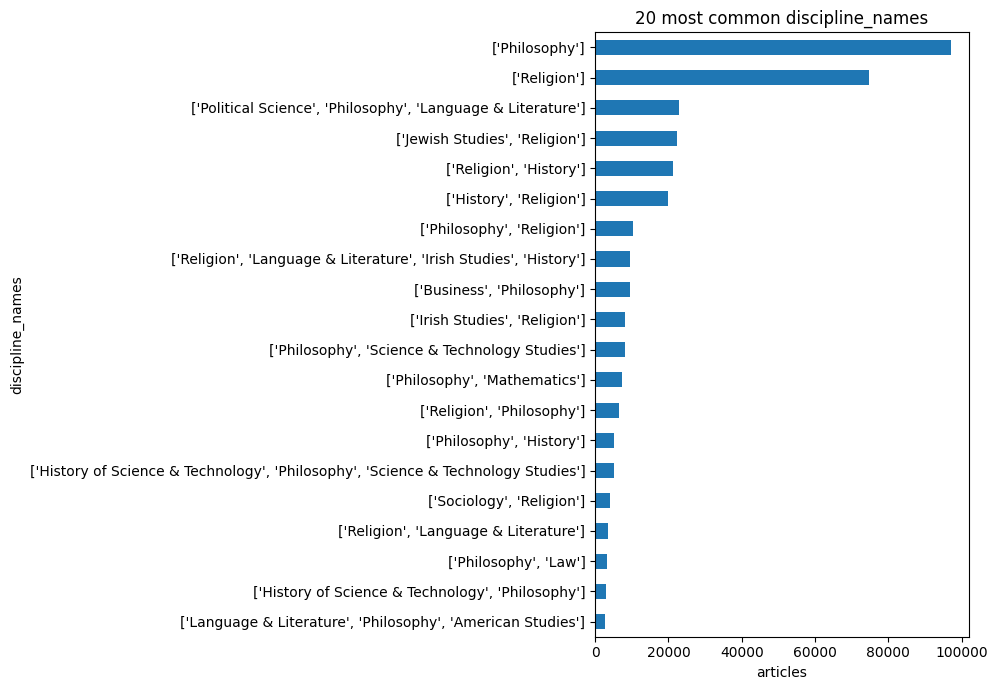

In [13]:
import matplotlib.pyplot as plt

top_disciplines = metadata.value_counts("discipline_names").head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_disciplines.sort_values().plot.barh(ax=ax)
ax.set_xlabel("articles")
ax.set_ylabel("discipline_names")
ax.set_title("20 most common discipline_names")
plt.tight_layout()

In [14]:
fig.savefig("../figures/20_most_common_discipline_combinations.png")

In [ ]:
#with open("/srv/data/jstor/jstor2026-04/f18084f6-06be-40e6-9ad0-8b2a6c33691f_unvalidated.txt", "r") as f:
#    unvalidated = f.read()

In [15]:
# unvalidated[-1000:]

In [14]:
sum(metadata["discipline_names"].apply(lambda x: "Religion" in x))

200667

In [16]:
metadata_religion = metadata[metadata["discipline_names"].apply(lambda x: "Religion" in x)]

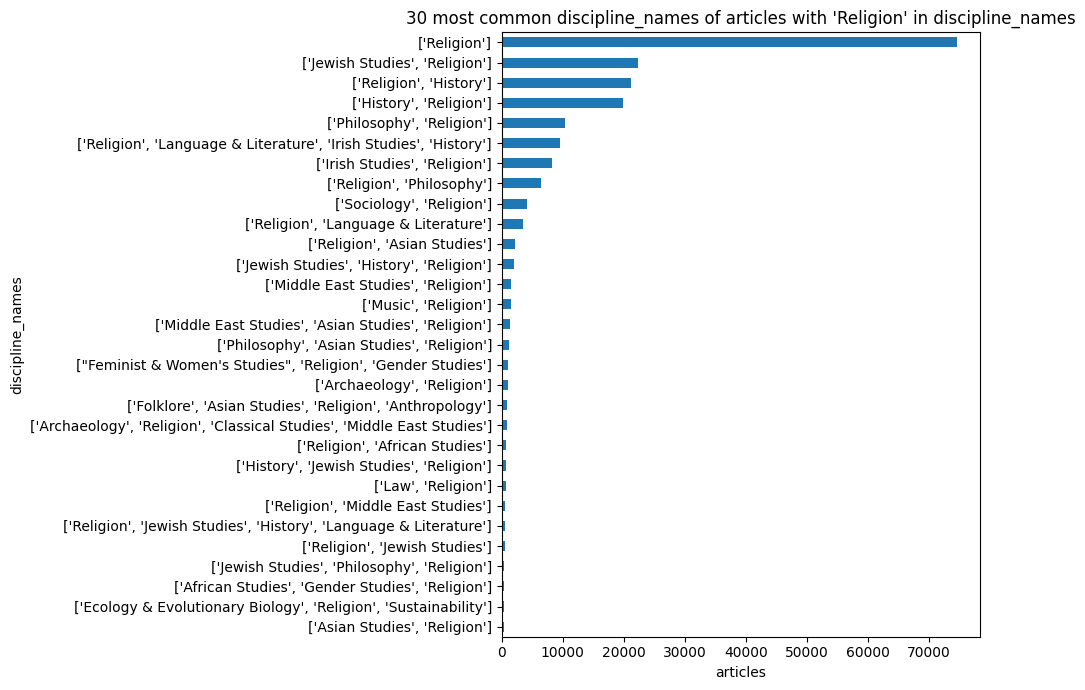

In [25]:
n = 30
top_disciplines_religion = metadata_religion.value_counts("discipline_names").head(n)

fig, ax = plt.subplots(figsize=(10, 7))
top_disciplines_religion.sort_values().plot.barh(ax=ax)
ax.set_xlabel("articles")
ax.set_ylabel("discipline_names")
ax.set_title(str(n) + " most common discipline_names of articles with 'Religion' in discipline_names")
plt.tight_layout()

In [27]:
fig.savefig("../figures/{}_most_common_discipline_combinations_religion.png".format(n)  )

In [30]:
metadata_religion.value_counts("is_part_of")

is_part_of
El Ciervo                                                                      12593
The Irish Monthly                                                               9511
The Furrow                                                                      7997
Bulletin de la Société de l'Histoire du Protestantisme Français (1903-2015)     4450
Studies: An Irish Quarterly Review                                              4332
                                                                               ...  
The American College Bulletin                                                     29
Journal of Jewish Lore and Philosophy                                             22
Historical Researches in Western Pennsylvania, Principally Catholic               14
Selected Papers from the Annual Meeting (Society of Christian Ethics)              6
Jewish Sociology and Social Research                                               5
Name: count, Length: 185, dtype: int64

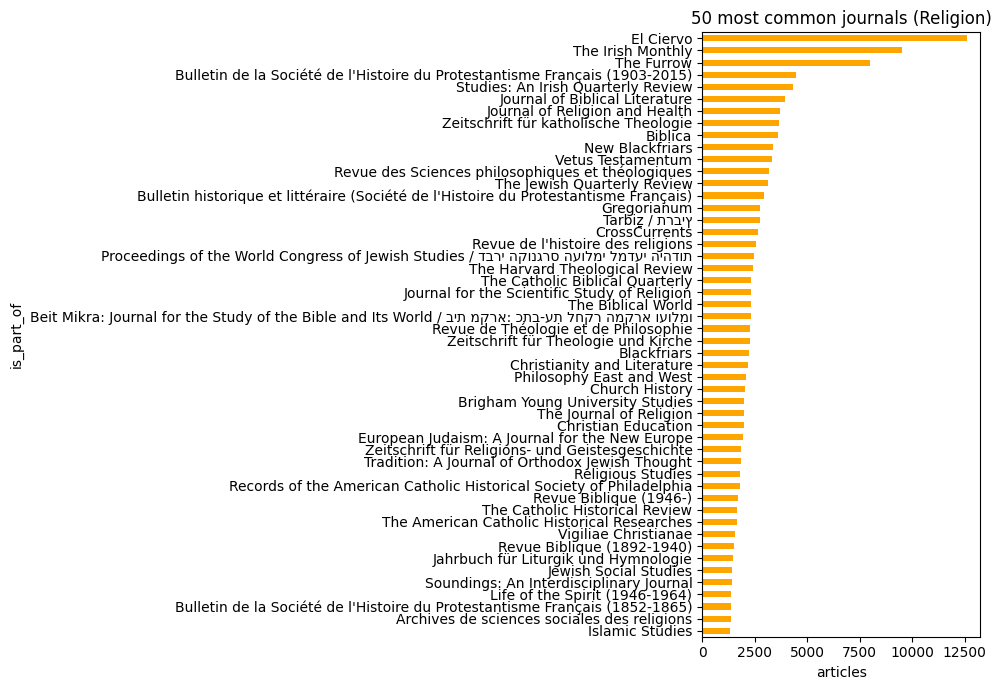

In [33]:
n = 50
top_journals_religion = metadata_religion.value_counts("is_part_of").head(n)

fig, ax = plt.subplots(figsize=(10, 7))
top_journals_religion.sort_values().plot.barh(ax=ax, color="orange")
ax.set_xlabel("articles")
ax.set_ylabel("is_part_of")
ax.set_title(f"{n} most common journals (Religion)")
plt.tight_layout()

In [34]:
fig.savefig("../figures/50_most_common_journals_religion.png")

In [18]:
metadata_religion.value_counts("is_part_of").to_csv("../data/journals_religion_2025.csv")

In [51]:
journals_counts = pd.DataFrame(
    metadata_religion.value_counts("is_part_of"),
    columns=["count"],
).rename_axis("is_part_of").reset_index()

In [ ]:
# google_conf.set_with_dataframe(mops_data.add_worksheet("journals_religion_counts", 1,1), journals_counts)

In [20]:
len(metadata_religion[metadata_religion["is_part_of"].isin(journals_annotated["Journal"])])

31229

## Full text as plain files (`fulltexts_txts/`, `references_txts`)

`/srv/data/jstor/jstor2026-04/jstor_fulltext_parser.py` flattened the 6 GB text delivery into one file per item, so opening an article is a single file read (~0.04 ms) instead of a ~105 s scan of the gzip stream. Run on 2026-09-04; full documentation is in the script's module docstring.

| path | contents |
| --- | --- |
| `fulltexts_txts/<item_id>.txt` | all OCR pages joined into continuous unpaged text — 384,807 files, 14.9 GiB |
| `references_txts/<item_id>.txt` | one bibliography entry per line; **absent** when the record has no references — 279,485 files, 1.2 GiB |
| `extract_logs/` | `extract_report.json` (run stats) and `extract_errors.log` (empty: 0 failures) |

* `iid` in the archive == `item_id` in `jstor_metadata_2026-04-28-filtered.csv`; ids are unique and 1:1 (22 CSV rows have no text, see `..._unvalidated.txt`).
* 295 text files are empty: those records contain whitespace-only OCR.
* Rebuild or resume: just re-run the script (`--overwrite` to force, `--verify` to check counts, `--dry-run` to cost a subset).
* Flat directory on purpose: lookup by exact name is hashed by ext4, only enumeration is slow; take journal subsets from the metadata CSV as id lists.

In [23]:
from pathlib import Path

JSTOR_TEXTS = Path("/srv/data/jstor/jstor2026-04/fulltexts_txts")
JSTOR_REFS = Path("/srv/data/jstor/jstor2026-04/references_txts")


def jstor_text(item_id: str) -> str:
    """Full text of one item as a single unpaged string ("" if unreadable OCR)."""
    return (JSTOR_TEXTS / f"{item_id}.txt").read_text(encoding="utf-8")


def jstor_references(item_id: str) -> list[str]:
    """Bibliography of one item, one entry per element ([] if the item has none)."""
    path = JSTOR_REFS / f"{item_id}.txt"
    return path.read_text(encoding="utf-8").splitlines() if path.exists() else []

In [21]:

# journal subset -> direct opens, no enumeration of the 384k-entry directory
subset = metadata_religion[metadata_religion["is_part_of"] == "Novum Testamentum"]
for item_id in subset["item_id"].head(3):
    text, refs = jstor_text(item_id), jstor_references(item_id)
    print(f"{item_id}  {len(text):>8,} chars  {len(refs):>3} refs  {text[:70]!r}")

dabe961c-e51e-30ed-988c-b5217b5b066a    10,010 chars   36 refs  'Novum Testamentum, Vol. XVII, fasc. 2 a... apv1a(k(oo &Laut6v..."? (Ma'
ead06e6a-6cfb-3804-a160-dddea33e8b87    30,104 chars   40 refs  'I m I Novum " \'??vs Testarnentum BRILL Novum Testarnentum 49 (2007) 85'
687b293b-8743-32b7-8245-1a20f9e022f6    30,718 chars   64 refs  'Novum Testamentum An International Quarterly (or New Testament and Rel'


In [24]:
len(os.listdir(JSTOR_TEXTS))

384807